In [1]:
import math

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from typing import Annotated, TypedDict
from langgraph.graph import add_messages
from langgraph.types import interrupt
import logging
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
from langgraph.types import Command
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
import requests
import json
from urllib.parse import urlparse, parse_qs
from langchain_core.messages import AIMessage, ToolMessage
from googleapiclient.discovery import build
from copy import deepcopy


logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='query_expansion_agent.log', # Saves to a file
    filemode='a'              # 'a' for append, 'w' to overwrite
)

logger = logging.getLogger(__name__)


In [2]:
load_dotenv(override=True)

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    openai_api_key=os.environ.get("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1"
)

API_KEY = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=API_KEY)

In [3]:

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    level : str
    query : str
    revised_query : str
    serper_results : list[str]
    authority_scores : list[float]
    recommendations : list[str]
    titles : list[str]
    channels : list[str]
    urls : dict[str, str]
    videos : list[dict[str,str]]
    no_of_videos : int
    learning_path : list[dict[str,str]]


In [4]:

def user_level_assessment_node(state : AgentState) -> AgentState:
    logger.info("User Level Assessment Node in Action")
    system_prompt = """
            You are an expert language analyst.

            Your task is to determine the learner's skill level from the user's query.

            Analyze the tone and keywords in the query to determine whether the user is:

            BEGINNER
            INTERMEDIATE
            ADVANCED
            UNKNOWN

            Guidelines:

            BEGINNER
            Queries that contain words such as:
            beginner, basics, introduction, getting started, noob, novice, simple explanation, fundamentals.

            INTERMEDIATE
            Queries that indicate some prior knowledge such as:
            intermediate, practical guide, tutorial, implementation, project-based learning.

            ADVANCED
            Queries that contain words such as:
            advanced, deep dive, expert, architecture, optimization, production systems, research.

            UNKNOWN
            If the query does not clearly indicate a skill level.

            Important rules:
            - Respond with ONLY ONE word.
            - Your response must be exactly one of these values:
            BEGINNER
            INTERMEDIATE
            ADVANCED
            UNKNOWN
            - Do not explain your answer.
            """
    messages = [SystemMessage(system_prompt), HumanMessage(state["query"])]
    response = llm.invoke(messages)
    logger.info(f"Level Assessment - {response.content}")
    return {"messages" : [response], "level" : response.content}


In [5]:
def query_expansion_node(state : AgentState) -> AgentState:
    logger.info("Query Expansion Node in Action")
    system_prompt = (
        f"""You are a Subject Matter Expert in Information Technology and your task is to recommend the right keywords to suggest the youtube videos that are based on student level i.e., Beginner to Advanced, keywords must best match with the provided query. The query is delimited by triple back ticks below
        ```{state["query"]}``` and revise the query as per student's level {state["level"]}. Provide just the final revised query as below:
        Revised Query : <query>
        """
    )
    response = llm.invoke(system_prompt)
    return {"messages" : [response], "revised_query" : response.content}


In [6]:
def confirm_user_level(state : AgentState) -> AgentState:
    level = interrupt(
       {
            "message": "Please provide your understanding level",
            "options": ["BEGINNER", "INTERMEDIATE", "ADVANCED"]
        }
    )
    return {
        "level": level,
    }

In [7]:
def should_continue(state: AgentState) -> str:
    if state["level"] == "UNKNOWN":
        return "confirm_user_level"
    return "query_expansion_node"

In [8]:
def get_video_id(url):
    parsed = urlparse(url)
    hostname = parsed.hostname

    if not hostname:
        return None

    # Short links
    if hostname == "youtu.be":
        return parsed.path.lstrip("/").split("?")[0]

    # Standard YouTube links
    if "youtube.com" in hostname:

        # watch?v=
        if parsed.path == "/watch":
            return parse_qs(parsed.query).get("v", [None])[0]

        # /shorts/
        if parsed.path.startswith("/shorts/"):
            return parsed.path.split("/")[2]

        # /embed/
        if parsed.path.startswith("/embed/"):
            return parsed.path.split("/")[2]

    return None

def serper_results_node(state: AgentState) -> AgentState:
    url = "https://google.serper.dev/search"
    payload = {
      "q": f"site:youtube.com {state["revised_query"].split(":")[-1].strip()}"
    }
    headers = {
      'X-API-KEY': os.environ["SERPER_API_KEY"],
      'Content-Type': 'application/json'
    }
    videos = []
    for page in range(2):
        payload["page"] = page + 1
        response = requests.request("POST", url, headers=headers, json=payload)
        results = json.loads(response.text)["organic"]
        for result in results:
            if "youtube.com" in result["link"]:
                videos.append(result["link"])
    video_ids = []
    urls = {}
    for video in videos:
        video_id = get_video_id(video)
        video_ids.append(video_id)
        urls[video_id] = video

    return {
        "serper_results" : video_ids,
        "urls" : urls,
        "revised_query" : state["revised_query"].split(":")[-1].strip()
    }


In [9]:
def get_counts(video_ids):
    request = youtube.videos().list(
            part="snippet,statistics,contentDetails",
            id=",".join([video for video in video_ids if video])
            )

    response = request.execute()
    video_summaries = {}
    for video in response["items"]:
        views = int(video.get("statistics", {}).get("viewCount", 0))
        likes = int(video.get("statistics", {}).get("likeCount", 0))
        comments = int(video.get("statistics", {}).get("commentCount", 0))
        video_summaries[video["id"]] = {"views" : views, "likes" : likes, "comments" : comments, "title": video["snippet"]["title"], "channelTitle" : video["snippet"]["channelTitle"], "description" : video["snippet"]["description"]}
    return video_summaries

def normalize(value, min_val, max_val):
    if max_val == min_val:
        return 0
    return (value - min_val) / (max_val - min_val)


def get_authority_scores(video_ids_dict):

    authority_scores_dict = deepcopy(video_ids_dict)

    views = [v["views"] for v in video_ids_dict.values()]
    engagements = [
        (v["likes"] + v["comments"]) / max(v["views"], 1)
        for v in video_ids_dict.values()
    ]

    min_views, max_views = min(views), max(views)
    min_eng, max_eng = min(engagements), max(engagements)

    for video_id, data in authority_scores_dict.items():

        view_score = normalize(
                        math.log10(data["views"] + 1),
                        math.log10(min_views + 1),
                        math.log10(max_views + 1)
                    )
        engagement = (data["likes"] + data["comments"]) / max(data["views"], 1)
        engagement_score = normalize(engagement, min_eng, max_eng)

        authority_score = 0.6 * view_score + 0.4 * engagement_score

        authority_scores_dict[video_id]["authority_score"] = round(authority_score, 2)

    return authority_scores_dict

def get_video_summaries(authority_scores_dict, urls):
    authority_scores = []
    recommendations = []
    titles = []
    channels = []
    video_ids = []
    focus_list = []
    for video_id in authority_scores_dict.keys():
        video_ids.append(video_id)
        focus_list.append(authority_scores_dict[video_id]["description"])
        authority_scores.append(authority_scores_dict[video_id]["authority_score"])
        score = authority_scores_dict[video_id]["authority_score"]
        titles.append(authority_scores_dict[video_id]["title"])
        channels.append(authority_scores_dict[video_id]["channelTitle"])
        if score >= 0.6:
            recommendations.append("recommended as core curriculum material")
        elif score >= 0.4:
            recommendations.append("recommended as primary supporting material")
        elif score >= 0.2:
            recommendations.append("suitable as supplementary learning")
        else:
            recommendations.append("optional reference material")

    videos = []
    for video_id, title, channel, authority_score, recommendation, focus in zip(video_ids, titles, channels, authority_scores, recommendations, focus_list):
        video_dict = {"title" : title, "channel" : channel, "authority_score" : authority_score, "recommendation" : recommendation, "url" : urls[video_id], "description" : focus}
        videos.append(video_dict)
    videos = sorted(videos, key=lambda x: x["authority_score"], reverse=True)
    return {
        "videos" : videos,
    }

def generate_video_summaries_node(state : AgentState) -> AgentState:
    serper_results = state["serper_results"]
    urls = state["urls"]
    video_ids_dict = get_counts(serper_results)
    authority_scores_dict = get_authority_scores(video_ids_dict)
    video_summaries = get_video_summaries(authority_scores_dict, urls)
    return video_summaries


In [10]:
def generate_learning_path_node(state : AgentState) -> AgentState:
    system_prompt = """
    You are an expert technical educator.

    Your task is to generate a short learning-focused briefing for a YouTube video.

    You will be given the following information about a video:
    - title
    - channel
    - description

    Write a concise briefing explaining what a learner will gain from watching this video.

    Guidelines:

    1. Focus on the learning outcome.
    2. Mention the key topic or concepts covered.
    3. Keep the explanation concise (1–2 sentences).
    4. Do NOT repeat the title.
    5. Do NOT include promotional language.
    6. Write in a clear and educational tone.

    Output format:

    Briefing: <very short explanation of what the learner will gain from the video>
    """

    videos = state["videos"]

    core = [v for v in videos if "core" in v["recommendation"]]
    primary = [v for v in videos if "primary" in v["recommendation"]]
    support = [v for v in videos if "support" in v["recommendation"]]
    optional = [v for v in videos if "optional" in v["recommendation"]]

    learning_path = []
    week = 1

    while core or primary or support or optional:

        videos_this_week = []

        # 1–2 core videos
        for _ in range(min(2, len(core))):
            videos_this_week.append(core.pop(0))

        # 1 primary video
        if primary:
            videos_this_week.append(primary.pop(0))

        # 1–2 support videos
        for _ in range(min(2, len(support))):
            videos_this_week.append(support.pop(0))

        # optional enrichment
        if optional:
            videos_this_week.append(optional.pop(0))

        titles = "\n".join([v["description"] for v in videos_this_week])

        user_prompt = f"""
        These videos will be watched on Week {week}.

        Videos:
        {titles}

        Write a short learning objective summarizing what the learner will gain.
        """

        focus = llm.invoke([
            AIMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]).content.split(":")[-1].strip()

        learning_path.append({
            "week": week,
            "focus": focus,
            "videos": videos_this_week
        })

        week += 1
    return {
        "learning_path": learning_path
    }


In [11]:
def save_results(state : AgentState) -> AgentState:
    serializable_state = state.copy()

    if "messages" in serializable_state:
        serializable_state["messages"] = [
            {"type": type(m).__name__, "content": m.content}
            for m in serializable_state["messages"]
        ]
    for key in ["messages", "urls", "serper_results", "recommendations", "authority_scores", "titles", "channels", "videos"]:
        serializable_state.pop(key, None)
    serializable_state["no_of_videos"] = len(serializable_state["learning_path"])
    with open("results1.json", "w", encoding="utf-8") as f:
        json.dump(serializable_state, f, indent=2)

    return state

In [12]:
workflow = StateGraph(AgentState)

workflow.add_node("user_level_assessment_node", user_level_assessment_node)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("confirm_user_level", confirm_user_level)
workflow.add_node("serper_results_node", serper_results_node)
workflow.add_node("generate_video_summaries_node", generate_video_summaries_node)
workflow.add_node("generate_learning_path_node", generate_learning_path_node)
workflow.add_node("save_results", save_results)

workflow.set_entry_point("user_level_assessment_node")
workflow.add_edge(START, "user_level_assessment_node")
workflow.add_conditional_edges(
    "user_level_assessment_node",
    should_continue,
    {
        "confirm_user_level": "confirm_user_level",
        "query_expansion_node": "query_expansion_node"
    }
)
workflow.add_edge("confirm_user_level", "query_expansion_node")
workflow.add_edge("query_expansion_node", "serper_results_node")
workflow.add_edge("serper_results_node", "generate_video_summaries_node")
workflow.add_edge("generate_video_summaries_node", "generate_learning_path_node")
workflow.add_edge("generate_learning_path_node", "save_results")
workflow.add_edge("save_results", END)
conn = sqlite3.connect("ai_university.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)
app = workflow.compile(checkpointer=memory)

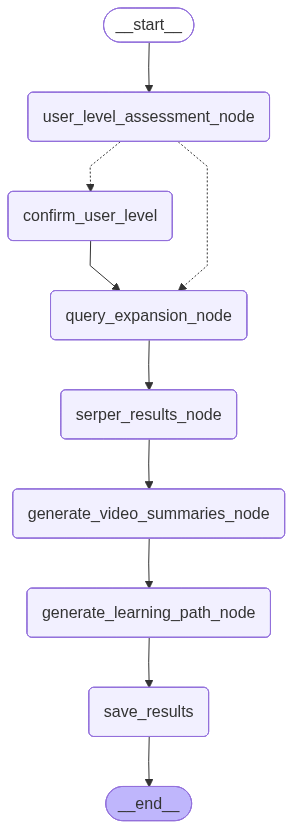

In [13]:
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
valid_levels = ['BEGINNER', 'INTERMEDIATE', 'ADVANCED']
initial_input = {"query" : "Agentic AI Beginner"}
config = {"configurable": {"thread_id": 7}}
state = app.invoke(initial_input, config=config)
while "__interrupt__" in state :
    interrupt_info = state["__interrupt__"][0].value

    print(interrupt_info["message"])
    user_input = input("Your answer: ").strip().upper()
    while user_input not in valid_levels:
        print("❌ Invalid input. Please choose one of:", valid_levels)
        user_input = input("Your answer: ").strip().upper()
    state = app.invoke(
        Command(resume=user_input),
        config=config
    )